In [1]:
import pandas as pd
import numpy as np
import os, sys
import matplotlib.pyplot as plt




In [2]:
#rank,caption,mean,precision,votes,not_funny,somewhat_funny,funny

path = "./data/newyorker_caption_contest/data/"
dirs = os.listdir(path)
files = [os.path.join(path,i) for i in os.listdir(path) if os.path.isfile(os.path.join(path,i))]


df = pd.DataFrame()

for file in files:
    
    data = pd.read_csv(file, sep=',')
    data['contest_id'] = os.path.split(file)[-1]
    df = pd.concat([df, data])
    
        

print(data.head())

                                             caption      mean  precision  \
0  Do you think death rays would be considered el...  1.632287   0.012004   
1                    Oh sure, now you look at a map.  1.632171   0.018294   
2                I've never heard of planet fitness.  1.626694   0.017874   
3  Wait, was it "conquer the mall" or "conquer th...  1.624266   0.020087   
4                          To Bed, Bath, and Beyond!  1.620504   0.013953   

   votes  not_funny  somewhat_funny  funny contest_id  
0   4014       2170            1150    694    895.csv  
1   1778        976             480    322    895.csv  
2   1918       1079             476    363    895.csv  
3   1533        870             369    294    895.csv  
4   2975       1640             824    511    895.csv  


In [3]:
df['contest_id'] = df['contest_id'].str.replace('.csv', '')  # Remove '.csv' from values
df.info()
df.head()


<class 'pandas.core.frame.DataFrame'>
Index: 2292678 entries, 0 to 4957
Data columns (total 9 columns):
 #   Column          Dtype  
---  ------          -----  
 0   rank            float64
 1   caption         object 
 2   mean            float64
 3   precision       float64
 4   votes           int64  
 5   not_funny       int64  
 6   somewhat_funny  int64  
 7   funny           int64  
 8   contest_id      object 
dtypes: float64(3), int64(4), object(2)
memory usage: 174.9+ MB


,rank,caption,mean,precision,votes,not_funny,somewhat_funny,funny,contest_id
0,0.0,I'm a congressman--obstruction is my job.,1.913043,0.094022,69,24,27,18,510
1,1.0,"I'm what they mean when they say, 'The middle ...",1.842105,0.191381,19,8,6,5,510
2,2.0,Does this suit make me look flat?,1.711111,0.112915,45,21,16,8,510
3,3.0,"When the right woman comes along, I'll know it.",1.625000,0.116657,32,15,14,3,510
4,4.0,"I used to lie in the gutter, but then I quit d...",1.617647,0.133610,34,19,9,6,510


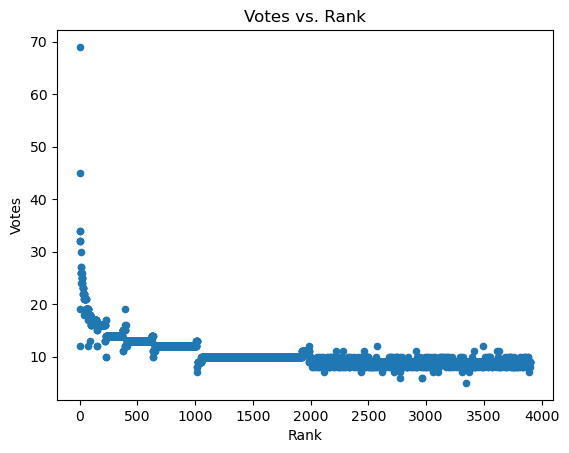

In [4]:
# Assuming 'df' is your DataFrame
df_filtered = df[df['contest_id'] == "510"]

# Creating the scatter plot
df_filtered.plot(kind='scatter', x='rank', y='votes', title='Votes vs. Rank', xlabel='Rank', ylabel='Votes')

# Show the plot
plt.show()

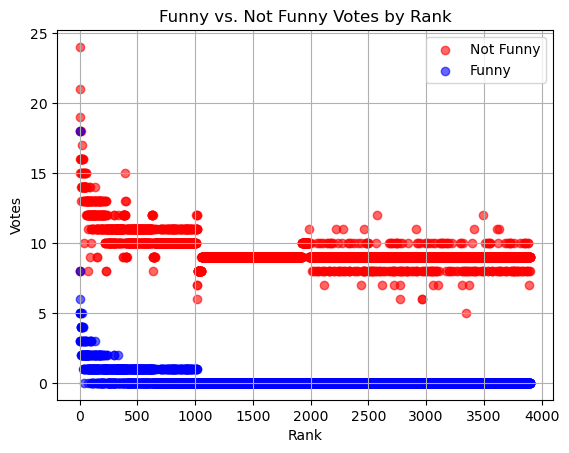

In [5]:
# Scatter plot for "not funny" votes
plt.scatter(df_filtered['rank'], df_filtered['not_funny'], color='red', label='Not Funny', alpha=0.6)

# Scatter plot for "funny" votes
plt.scatter(df_filtered['rank'], df_filtered['funny'], color='blue', label='Funny', alpha=0.6)


# Adding titles and labels
plt.title('Funny vs. Not Funny Votes by Rank')
plt.xlabel('Rank')
plt.ylabel('Votes')
plt.legend()  # Show legend
plt.grid(True)  # Optional: Adding grid for better readability
plt.show()

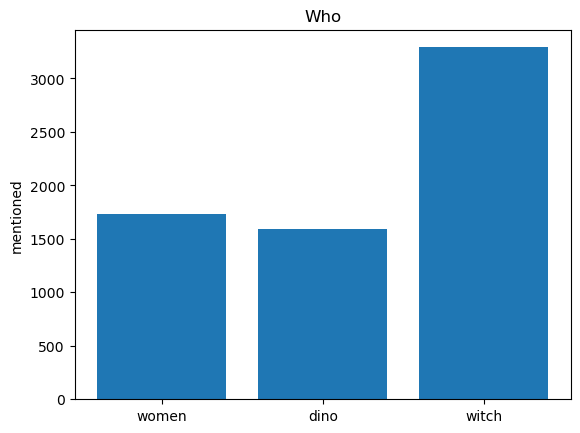

In [22]:
women_count = df['caption'].str.contains('women').sum()

#print(df_filtered['caption'].str.contains('women').sum())

men_count = df['caption'].str.contains('men').sum() - women_count

dino_count = df['caption'].str.contains('dino').sum()

witch_count = df['caption'].str.contains('witch').sum()


fig, ax = plt.subplots()

words = ['women',  'dino', 'witch'] #had to remove men, cause its so much more
counts = [women_count, dino_count, witch_count]


ax.bar(words, counts)

ax.set_ylabel('mentioned')
ax.set_title('Who')


plt.show()

